# Confidence-4 Upsampling + Noisy Random Sampling - 1-layer MLP Regression

This notebook first creates validation/test splits from the original confidence 1-5 data. Only the train split is balanced against confidence 4. Duplicated upsampled rows receive random noise on CLAP embedding dimensions.

In [3]:
# =====================================================
# 1. IMPORTS AND REPRODUCIBILITY
# =====================================================
import os
import random
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from IPython.display import display, Image
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    mean_absolute_error,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)


DEVICE: cuda


In [4]:
# =====================================================
# 2. GOOGLE DRIVE MOUNT
# =====================================================
if IN_COLAB:
    drive.mount("/content/drive")

# =====================================================
# 3. PATH SETTINGS
# =====================================================
# Drive original paths
METADATA_CSV = "/content/drive/MyDrive/DCASE2026/data/metadata/BSD10k_metadata.csv"

DRIVE_AUDIO_EMB_DIR = "/content/drive/MyDrive/DCASE2026/data/features/clap_audio_embeddings"
DRIVE_TEXT_EMB_DIR  = "/content/drive/MyDrive/DCASE2026/data/features/clap_text_embeddings"

# Colab local paths
LOCAL_BASE_DIR = "/content/bsd10k_features"

AUDIO_EMB_DIR = os.path.join(
    LOCAL_BASE_DIR,
    "clap_audio_embeddings"
)

TEXT_EMB_DIR = os.path.join(
    LOCAL_BASE_DIR,
    "clap_text_embeddings"
)

# Column names
SOUND_ID_COL = "sound_id"
CLASS_COL = "class"
CONFIDENCE_COL = "confidence"

OUTPUT_BASE_DIR = "/content/drive/MyDrive/DCASE2026/outputs/up_sampling_confi4"

print("METADATA_CSV:", METADATA_CSV)
print("DRIVE_AUDIO_EMB_DIR:", DRIVE_AUDIO_EMB_DIR)
print("DRIVE_TEXT_EMB_DIR:", DRIVE_TEXT_EMB_DIR)
print("AUDIO_EMB_DIR:", AUDIO_EMB_DIR)
print("TEXT_EMB_DIR:", TEXT_EMB_DIR)
print("OUTPUT_BASE_DIR:", OUTPUT_BASE_DIR)


Mounted at /content/drive
METADATA_CSV: /content/drive/MyDrive/DCASE2026/data/metadata/BSD10k_metadata.csv
DRIVE_AUDIO_EMB_DIR: /content/drive/MyDrive/DCASE2026/data/features/clap_audio_embeddings
DRIVE_TEXT_EMB_DIR: /content/drive/MyDrive/DCASE2026/data/features/clap_text_embeddings
AUDIO_EMB_DIR: /content/bsd10k_features/clap_audio_embeddings
TEXT_EMB_DIR: /content/bsd10k_features/clap_text_embeddings
OUTPUT_BASE_DIR: /content/drive/MyDrive/DCASE2026/outputs/up_sampling_confi4


In [5]:
# =====================================================
# 4. EXPERIMENT SETTINGS
# =====================================================
TEST_SIZE = 0.20
VALID_SIZE = 0.20
BATCH_SIZE = 256
NUM_EPOCHS = 120
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 15

# Noise is applied only to duplicated upsampled embedding values, not to original rows.
NOISE_STD = 0.01

# If any non-4 confidence class has more samples than confidence 4 in train,
# set True to force exact count matching by random downsampling.
# For pure upsampling only, keep False.
DOWNSAMPLE_IF_ABOVE_TARGET = False

USE_AUDIO_EMB = True
USE_TEXT_EMB = True
USE_CLASS_ONEHOT = True
USE_DESCRIPTION_LENGTH = False

LABELS = [1, 2, 3, 4, 5]


In [6]:
# =====================================================
# 5. DATA LOADING AND PREPROCESSING
# =====================================================
def copy_drive_features_to_local():
    """Copy Drive embeddings to Colab local disk for faster np.load calls."""
    Path(LOCAL_BASE_DIR).mkdir(parents=True, exist_ok=True)
    for src, dst in [
        (DRIVE_AUDIO_EMB_DIR, AUDIO_EMB_DIR),
        (DRIVE_TEXT_EMB_DIR, TEXT_EMB_DIR),
    ]:
        src_path = Path(src)
        dst_path = Path(dst)
        if dst_path.exists() and any(dst_path.iterdir()):
            print(f"Already exists: {dst_path}")
            continue
        print(f"Copying {src_path} -> {dst_path}")
        shutil.copytree(src_path, dst_path, dirs_exist_ok=True)


def finite_float32(x):
    return np.nan_to_num(
        np.asarray(x, dtype=np.float32),
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    ).astype(np.float32)


def clean_metadata(df):
    df = df.copy()
    df[SOUND_ID_COL] = df[SOUND_ID_COL].astype(str).str.strip()
    df[CLASS_COL] = df[CLASS_COL].astype(str).str.strip()
    df[CONFIDENCE_COL] = pd.to_numeric(df[CONFIDENCE_COL], errors="coerce")
    df = df[df[CONFIDENCE_COL].isin(LABELS)].copy()
    df[CONFIDENCE_COL] = df[CONFIDENCE_COL].astype(int)

    # Follow the existing repository convention: remove class_idx values ending in 99 or 00 when present.
    if "class_idx" in df.columns:
        class_idx = df["class_idx"].astype(str).str.strip()
        keep = ~((class_idx.str.len() == 3) & (class_idx.str.endswith("99") | class_idx.str.endswith("00")))
        df = df[keep].copy()

    return df.reset_index(drop=True)


def one_hot(values, categories):
    category_to_idx = {category: idx for idx, category in enumerate(categories)}
    arr = np.zeros((len(values), len(categories)), dtype=np.float32)
    for row_idx, value in enumerate(values):
        arr[row_idx, category_to_idx[str(value)]] = 1.0
    return arr


def load_embedding(path):
    return finite_float32(np.load(path).reshape(-1))


def build_dataset():
    copy_drive_features_to_local()

    meta = clean_metadata(pd.read_csv(METADATA_CSV))
    audio_dir = Path(AUDIO_EMB_DIR)
    text_dir = Path(TEXT_EMB_DIR)

    kept_rows = []
    audio_rows = []
    text_rows = []

    for _, row in meta.iterrows():
        sound_id = str(row[SOUND_ID_COL])
        audio_path = audio_dir / f"{sound_id}.npy"
        text_path = text_dir / f"{sound_id}.npy"
        if audio_path.is_file() and text_path.is_file():
            kept_rows.append(row)
            audio_rows.append(load_embedding(audio_path))
            text_rows.append(load_embedding(text_path))

    df = pd.DataFrame(kept_rows).reset_index(drop=True)
    audio = finite_float32(np.vstack(audio_rows))
    text = finite_float32(np.vstack(text_rows))

    categories = sorted(df[CLASS_COL].astype(str).unique().tolist())
    feature_parts = []
    noise_slices = []
    start = 0

    if USE_AUDIO_EMB:
        feature_parts.append(audio)
        noise_slices.append(slice(start, start + audio.shape[1]))
        start += audio.shape[1]
        print("audio:", audio.shape)

    if USE_TEXT_EMB:
        feature_parts.append(text)
        noise_slices.append(slice(start, start + text.shape[1]))
        start += text.shape[1]
        print("text:", text.shape)

    if USE_CLASS_ONEHOT:
        class_oh = one_hot(df[CLASS_COL].astype(str).tolist(), categories)
        feature_parts.append(class_oh)
        start += class_oh.shape[1]
        print("class_onehot:", class_oh.shape)

    if USE_DESCRIPTION_LENGTH:
        desc = df["description"] if "description" in df.columns else pd.Series([""] * len(df))
        desc_len = desc.fillna("").astype(str).str.len().to_numpy(dtype=np.float32).reshape(-1, 1)
        feature_parts.append(desc_len)
        start += 1
        print("description_length:", desc_len.shape)

    X = finite_float32(np.concatenate(feature_parts, axis=1))
    y = df[CONFIDENCE_COL].to_numpy(dtype=np.int64)

    noise_mask = np.zeros(X.shape[1], dtype=bool)
    for s in noise_slices:
        noise_mask[s] = True

    print("samples:", len(df), "features:", X.shape[1])
    display(pd.Series(y).value_counts().reindex(LABELS, fill_value=0).rename("full_data_confidence_count"))
    return df, X, y, noise_mask, categories


def make_splits(y):
    idx = np.arange(len(y))
    train_idx, temp_idx = train_test_split(
        idx,
        test_size=TEST_SIZE + VALID_SIZE,
        random_state=SEED,
        stratify=y,
    )
    relative_test_size = TEST_SIZE / (TEST_SIZE + VALID_SIZE)
    valid_idx, test_idx = train_test_split(
        temp_idx,
        test_size=relative_test_size,
        random_state=SEED,
        stratify=y[temp_idx],
    )
    return train_idx, valid_idx, test_idx


def upsample_train_to_confidence4(X_train, y_train, noise_mask):
    rng = np.random.default_rng(SEED)
    before = pd.Series(y_train).value_counts().reindex(LABELS, fill_value=0).astype(int)
    target_n = int(before.loc[4])
    if target_n <= 0:
        raise ValueError("confidence 4 count is zero in the train split.")

    x_parts = []
    y_parts = []
    aug_flags = []
    plan_rows = []

    for label in LABELS:
        label_pos = np.flatnonzero(y_train == label)
        current_n = len(label_pos)
        if current_n == 0:
            raise ValueError(f"confidence {label} count is zero in the train split.")

        if label == 4:
            chosen_original = label_pos
            duplicate_pos = np.array([], dtype=np.int64)
            action = "target_keep_original"
        elif current_n < target_n:
            chosen_original = label_pos
            duplicate_pos = rng.choice(label_pos, size=target_n - current_n, replace=True)
            action = "upsample_with_noise"
        elif current_n > target_n and DOWNSAMPLE_IF_ABOVE_TARGET:
            chosen_original = rng.choice(label_pos, size=target_n, replace=False)
            duplicate_pos = np.array([], dtype=np.int64)
            action = "downsample_to_target"
        else:
            chosen_original = label_pos
            duplicate_pos = np.array([], dtype=np.int64)
            action = "keep_original_above_target" if current_n > target_n else "keep_original_equal_target"

        x_original = X_train[chosen_original].copy()
        y_original = y_train[chosen_original].copy()
        x_parts.append(x_original)
        y_parts.append(y_original)
        aug_flags.extend([False] * len(x_original))

        if len(duplicate_pos) > 0:
            x_dup = X_train[duplicate_pos].copy()
            noise = rng.normal(loc=0.0, scale=NOISE_STD, size=x_dup[:, noise_mask].shape).astype(np.float32)
            x_dup[:, noise_mask] = x_dup[:, noise_mask] + noise
            y_dup = y_train[duplicate_pos].copy()
            x_parts.append(x_dup)
            y_parts.append(y_dup)
            aug_flags.extend([True] * len(x_dup))

        plan_rows.append({
            "confidence": label,
            "before": current_n,
            "target_confidence4_count": target_n,
            "added_noisy_duplicates": int(len(duplicate_pos)),
            "after": int(len(chosen_original) + len(duplicate_pos)),
            "action": action,
        })

    X_bal = finite_float32(np.vstack(x_parts))
    y_bal = np.concatenate(y_parts).astype(np.int64)
    aug_flags = np.asarray(aug_flags, dtype=bool)

    order = rng.permutation(len(y_bal))
    X_bal = X_bal[order]
    y_bal = y_bal[order]
    aug_flags = aug_flags[order]

    plan = pd.DataFrame(plan_rows)
    after = pd.Series(y_bal).value_counts().reindex(LABELS, fill_value=0).astype(int)
    plan["actual_after"] = plan["confidence"].map(after.to_dict())
    return X_bal, y_bal, aug_flags, plan


def make_loader(X_np, y_np, batch_size=BATCH_SIZE, shuffle=False, classification=True):
    x_tensor = torch.from_numpy(finite_float32(X_np))
    if classification:
        y_tensor = torch.from_numpy((y_np.astype(np.int64) - 1))
    else:
        y_tensor = torch.from_numpy(y_np.astype(np.float32))
    dataset = TensorDataset(x_tensor, y_tensor)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, num_workers=0, pin_memory=torch.cuda.is_available())


def classification_metrics(y_true, y_pred_class, mae_score=None):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred_class,
        labels=LABELS,
        average="macro",
        zero_division=0,
    )
    mae_source = y_pred_class if mae_score is None else mae_score
    return {
        "accuracy": float(accuracy_score(y_true, y_pred_class)),
        "macro_precision": float(precision),
        "macro_recall": float(recall),
        "macro_f1": float(f1),
        "mae": float(mean_absolute_error(y_true, mae_source)),
    }


def save_loss_curve(history, title, out_path):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(history["epoch"], history["train_loss"], label="train loss")
    ax.plot(history["epoch"], history["val_loss"], label="validation loss")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()
    fig.savefig(out_path, dpi=160)
    plt.show()


def save_confusion(y_true, y_pred, title, out_path):
    cm = confusion_matrix(y_true, y_pred, labels=LABELS)
    cm_norm = cm.astype(np.float32) / np.maximum(cm.sum(axis=1, keepdims=True), 1)

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm_norm, vmin=0.0, vmax=1.0, cmap="Blues")
    ax.set_title(title)
    ax.set_xlabel("Predicted confidence")
    ax.set_ylabel("True confidence")
    ax.set_xticks(range(len(LABELS)), LABELS)
    ax.set_yticks(range(len(LABELS)), LABELS)
    for i in range(len(LABELS)):
        for j in range(len(LABELS)):
            ax.text(j, i, f"{cm_norm[i, j] * 100:.1f}%", ha="center", va="center", fontsize=8)
    fig.colorbar(im, ax=ax)
    fig.tight_layout()
    fig.savefig(out_path, dpi=160)
    plt.show()
    return cm, cm_norm


In [7]:
# =====================================================
# 6. SPLIT FIRST, THEN TRAIN-ONLY CONFIDENCE-4 UPSAMPLING
# =====================================================
df, X, y, noise_mask, class_categories = build_dataset()
train_idx, valid_idx, test_idx = make_splits(y)

X_train_raw = X[train_idx]
y_train_raw = y[train_idx]
X_valid_raw = X[valid_idx]
y_valid = y[valid_idx]
X_test_raw = X[test_idx]
y_test = y[test_idx]

X_train_bal_raw, y_train_bal, is_noisy_duplicate, resample_plan = upsample_train_to_confidence4(
    X_train_raw,
    y_train_raw,
    noise_mask,
)

# Fit scaler on the original train split, then transform balanced train/valid/test.
scaler = StandardScaler()
scaler.fit(X_train_raw)
X_train = scaler.transform(X_train_bal_raw).astype(np.float32)
X_valid = scaler.transform(X_valid_raw).astype(np.float32)
X_test = scaler.transform(X_test_raw).astype(np.float32)

print("split before upsampling:", len(train_idx), len(valid_idx), len(test_idx))
print("train after upsampling:", len(X_train))
print("noisy duplicated train rows:", int(is_noisy_duplicate.sum()))

print("\nTrain distribution before upsampling")
display(pd.Series(y_train_raw).value_counts().reindex(LABELS, fill_value=0).rename("train_before"))

print("\nConfidence-4 upsampling plan")
display(resample_plan)

print("\nTrain distribution after upsampling")
display(pd.Series(y_train_bal).value_counts().reindex(LABELS, fill_value=0).rename("train_after"))

print("\nValidation distribution is unchanged")
display(pd.Series(y_valid).value_counts().reindex(LABELS, fill_value=0).rename("validation"))

print("\nTest distribution is unchanged")
display(pd.Series(y_test).value_counts().reindex(LABELS, fill_value=0).rename("test"))


Copying /content/drive/MyDrive/DCASE2026/data/features/clap_audio_embeddings -> /content/bsd10k_features/clap_audio_embeddings
Copying /content/drive/MyDrive/DCASE2026/data/features/clap_text_embeddings -> /content/bsd10k_features/clap_text_embeddings
audio: (10956, 512)
text: (10956, 512)
class_onehot: (10956, 23)
samples: 10956 features: 1047


,full_data_confidence_count
1,107
2,748
3,3281
4,6043
5,777


split before upsampling: 6573 2191 2192
train after upsampling: 18130
noisy duplicated train rows: 11557

Train distribution before upsampling


,train_before
1,64
2,449
3,1968
4,3626
5,466



Confidence-4 upsampling plan


...

,train_after
1,3626
2,3626
3,3626
4,3626
5,3626



Validation distribution is unchanged


,validation
1,22
2,150
3,656
4,1208
5,155



Test distribution is unchanged


,test
1,21
2,149
3,657
4,1209
5,156


[001/120] train_loss=9.8825 val_loss=14.0702 val_f1=0.0149 val_mae=2.4682
[010/120] train_loss=6.4941 val_loss=9.9621 val_f1=0.0234 val_mae=2.3454
[020/120] train_loss=4.2279 val_loss=6.4724 val_f1=0.0393 val_mae=2.1713
[030/120] train_loss=2.7193 val_loss=4.0761 val_f1=0.0573 val_mae=1.8165
[040/120] train_loss=1.7769 val_loss=2.5550 val_f1=0.1191 val_mae=1.4055
[050/120] train_loss=1.2930 val_loss=1.6394 val_f1=0.2110 val_mae=1.0876
[060/120] train_loss=1.0765 val_loss=1.1316 val_f1=0.2631 val_mae=0.8814
[070/120] train_loss=1.0135 val_loss=0.9597 val_f1=0.2881 val_mae=0.7930
[080/120] train_loss=0.9981 val_loss=0.8585 val_f1=0.2989 val_mae=0.7472
[090/120] train_loss=1.0039 val_loss=0.8605 val_f1=0.3059 val_mae=0.7460
[100/120] train_loss=1.0102 val_loss=0.8653 val_f1=0.2950 val_mae=0.7466
[110/120] train_loss=1.0043 val_loss=0.8882 val_f1=0.3022 val_mae=0.7573
Early stopping at epoch 119


,split,accuracy,macro_precision,macro_recall,macro_f1,mae
0,validation,0.414879,0.329513,0.314927,0.293956,0.727204
1,test,0.396442,0.320366,0.308320,0.285730,0.746794


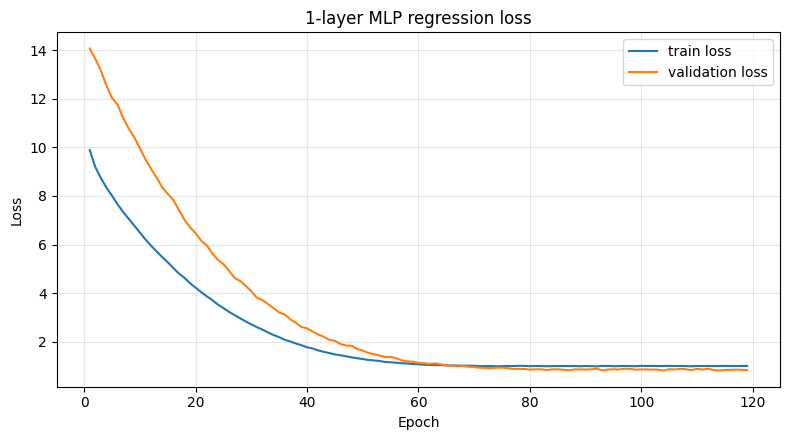

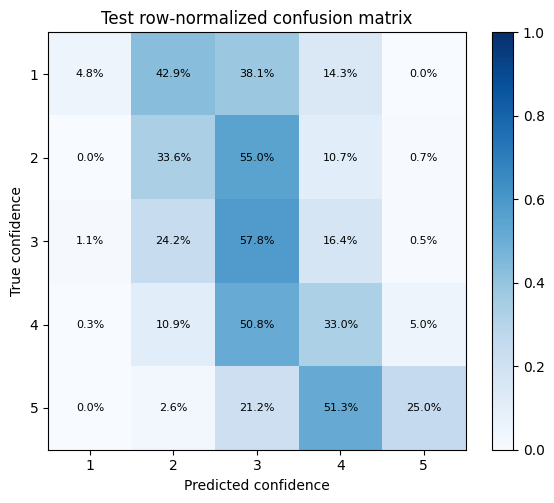

Saved to: /content/drive/MyDrive/DCASE2026/outputs/up_sampling_confi4/confidence4_upsample_noisy_1layer_mlp_regression


In [8]:
# =====================================================
# 7. 1-LAYER MLP REGRESSION
# =====================================================
EXPERIMENT_NAME = "confidence4_upsample_noisy_1layer_mlp_regression"
OUTPUT_DIR = Path(OUTPUT_BASE_DIR) / EXPERIMENT_NAME
REPORT_DIR = OUTPUT_DIR / "reports"
PLOT_DIR = OUTPUT_DIR / "plots"
PRED_DIR = OUTPUT_DIR / "predictions"
for path in [REPORT_DIR, PLOT_DIR, PRED_DIR]:
    path.mkdir(parents=True, exist_ok=True)

resample_plan.to_csv(REPORT_DIR / "resample_plan.csv", index=False)

class OneLayerMLPRegressor(nn.Module):
    def __init__(self, input_dim, dropout=0.4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(input_dim, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(1)


@torch.no_grad()
def predict_regressor(model, X_np, y_np):
    loader = make_loader(X_np, y_np, shuffle=False, classification=False)
    model.eval()
    score_chunks = []
    true_chunks = []
    for xb, yb in loader:
        xb = xb.to(DEVICE, non_blocking=True)
        score = model(xb).detach().cpu().numpy()
        score = np.clip(score, 1.0, 5.0)
        score_chunks.append(score)
        true_chunks.append(yb.numpy().astype(np.float32))
    y_true_float = np.concatenate(true_chunks)
    y_score = np.concatenate(score_chunks)
    y_true_class = np.rint(y_true_float).astype(np.int64)
    y_pred_class = np.rint(y_score).clip(1, 5).astype(np.int64)
    return y_true_class, y_pred_class, y_score


model = OneLayerMLPRegressor(input_dim=X_train.shape[1]).to(DEVICE)
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

train_loader = make_loader(X_train, y_train_bal, shuffle=True, classification=False)
valid_loader = make_loader(X_valid, y_valid, shuffle=False, classification=False)

best_state = None
best_val_loss = float("inf")
bad_epochs = 0
history_rows = []

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    train_loss_sum = 0.0
    train_seen = 0
    for xb, yb in train_loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        train_loss_sum += float(loss.item()) * xb.size(0)
        train_seen += xb.size(0)

    model.eval()
    val_loss_sum = 0.0
    val_seen = 0
    with torch.no_grad():
        for xb, yb in valid_loader:
            xb = xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True)
            pred = model(xb)
            loss = criterion(pred, yb)
            val_loss_sum += float(loss.item()) * xb.size(0)
            val_seen += xb.size(0)

    train_loss = train_loss_sum / max(train_seen, 1)
    val_loss = val_loss_sum / max(val_seen, 1)
    val_true, val_pred, val_score = predict_regressor(model, X_valid, y_valid)
    val_metrics = classification_metrics(val_true, val_pred, mae_score=val_score)

    history_rows.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        **{f"val_{k}": v for k, v in val_metrics.items()},
    })

    if epoch == 1 or epoch % 10 == 0:
        print(f"[{epoch:03d}/{NUM_EPOCHS}] train_loss={train_loss:.4f} val_loss={val_loss:.4f} val_f1={val_metrics['macro_f1']:.4f} val_mae={val_metrics['mae']:.4f}")

    if val_loss < best_val_loss - 1e-6:
        best_val_loss = val_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        bad_epochs = 0
    else:
        bad_epochs += 1
        if bad_epochs >= PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

model.load_state_dict(best_state)
history = pd.DataFrame(history_rows)
history.to_csv(REPORT_DIR / "history.csv", index=False)
torch.save(model.state_dict(), OUTPUT_DIR / "best_model.pth")

val_true, val_pred, val_score = predict_regressor(model, X_valid, y_valid)
test_true, test_pred, test_score = predict_regressor(model, X_test, y_test)
val_metrics = classification_metrics(val_true, val_pred, mae_score=val_score)
test_metrics = classification_metrics(test_true, test_pred, mae_score=test_score)

summary = pd.DataFrame([
    {"split": "validation", **val_metrics},
    {"split": "test", **test_metrics},
])
summary.to_csv(REPORT_DIR / "metrics_summary.csv", index=False)
display(summary)

save_loss_curve(history, "1-layer MLP regression loss", PLOT_DIR / "train_val_loss.png")

cm, cm_norm = save_confusion(test_true, test_pred, "Test row-normalized confusion matrix", PLOT_DIR / "test_confusion_row_normalized.png")
pd.DataFrame(cm, index=[f"true_{i}" for i in LABELS], columns=[f"pred_{i}" for i in LABELS]).to_csv(REPORT_DIR / "test_confusion_counts.csv")
pd.DataFrame(cm_norm, index=[f"true_{i}" for i in LABELS], columns=[f"pred_{i}" for i in LABELS]).to_csv(REPORT_DIR / "test_confusion_row_normalized.csv")

pred_out = df.iloc[test_idx][[SOUND_ID_COL, CLASS_COL, CONFIDENCE_COL]].copy()
pred_out["predicted_confidence_score"] = test_score
pred_out["predicted_confidence_round"] = test_pred
pred_out.to_csv(PRED_DIR / "test_predictions.csv", index=False)

print("Saved to:", OUTPUT_DIR)


,split,accuracy,macro_precision,macro_recall,macro_f1,mae
0,validation,0.414879,0.329513,0.314927,0.293956,0.727204
1,test,0.396442,0.320366,0.308320,0.285730,0.746794


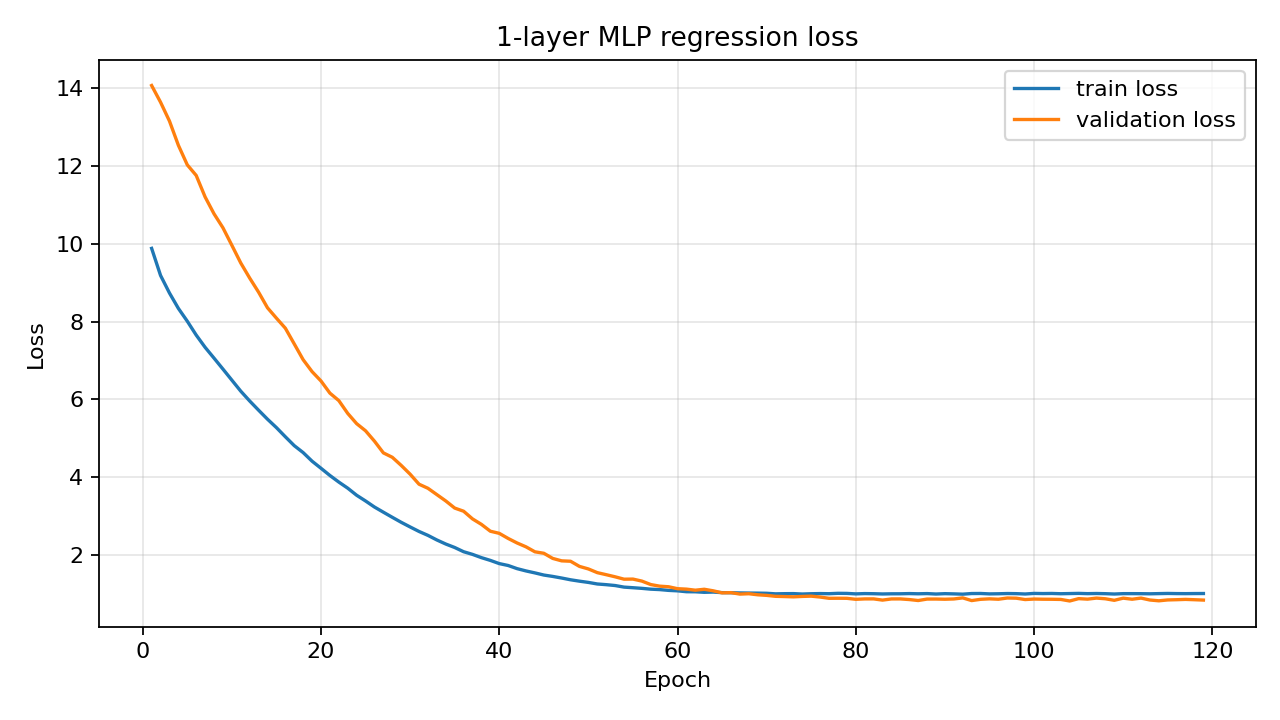

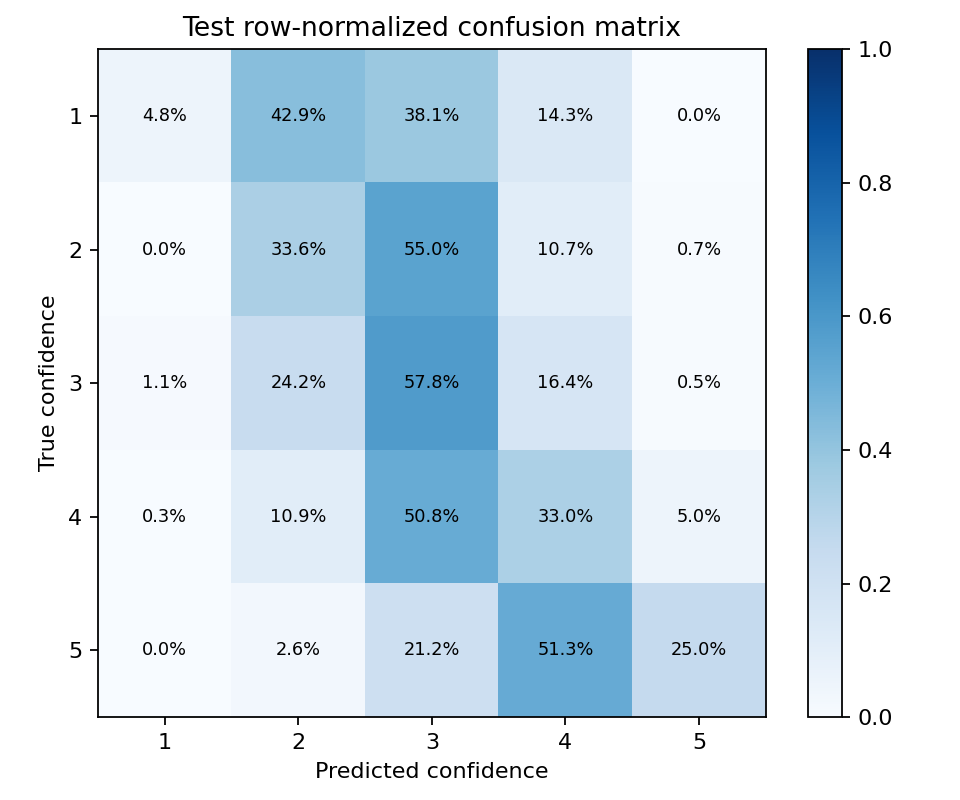

In [9]:
# =====================================================
# 8. RESULT FILES
# =====================================================
display(pd.read_csv(REPORT_DIR / "metrics_summary.csv"))
display(Image(filename=str(PLOT_DIR / "train_val_loss.png")))
display(Image(filename=str(PLOT_DIR / "test_confusion_row_normalized.png")))
